In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# 1. Tải dữ liệu từ tfds
(train_ds, validation_ds), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,
)

# 2. Tiền xử lý dữ liệu
IMG_SIZE = 150

def format_example(image, label):
    image = tf.cast(image, tf.float32)
    image = (image / 127.5) - 1 # Normalize về khoảng [-1, 1]
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train = train_ds.map(format_example).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
validation = validation_ds.map(format_example).batch(32).prefetch(tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.5TJ0BM_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
# 3. Xây dựng mô hình CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. Huấn luyện mô hình
history = model.fit(
    train,
    epochs=10,
    validation_data=validation
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 54s 77ms/step - accuracy: 0.5523 - loss: 0.6906 - val_accuracy: 0.6853 - val_loss: 0.5920
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.7426 - loss: 0.5167 - val_accuracy: 0.7928 - val_loss: 0.4525
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.8175 - loss: 0.3996 - val_accuracy: 0.7928 - val_loss: 0.4522
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.8805 - loss: 0.2782 - val_accuracy: 0.8029 - val_loss: 0.4890
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9478 - loss: 0.1333 - val_accuracy: 0.7988 - val_loss: 0.7546
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.9795 - loss: 0.0585 - val_accuracy: 0.8048 - val_loss: 0.9180
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 44s 74ms/step - accuracy: 0.9875 - loss: 0.0380 - val_accuracy: 0.7982 - val_loss: 1.1023
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 44s 72ms/step - accuracy: 0.9895 - loss: 0.0336 - 

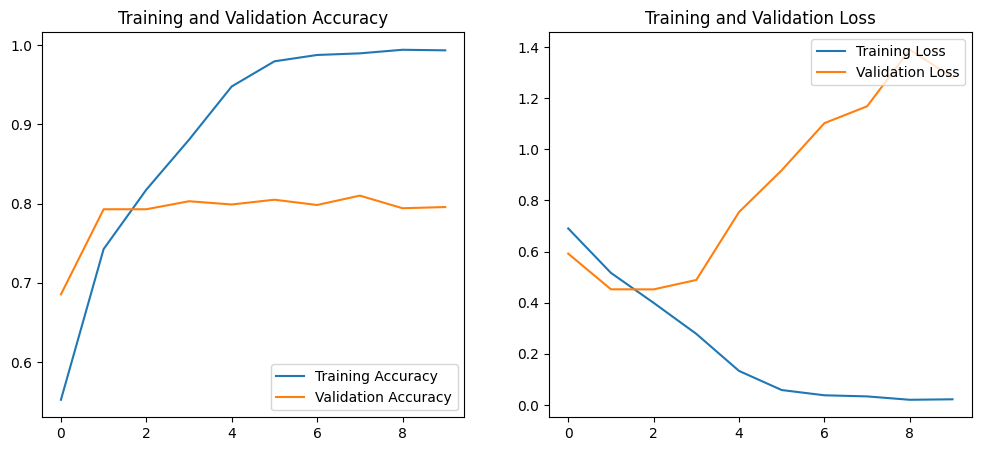

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step


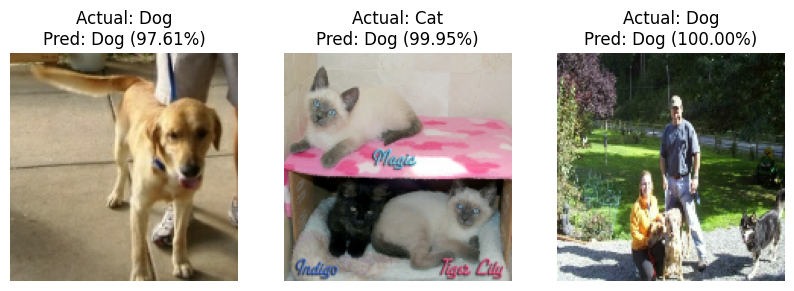

In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# Lấy một vài mẫu từ tập validation để test nhanh
for img_batch, label_batch in validation.take(1):
    prediction = model.predict(img_batch)

    plt.figure(figsize=(10, 10))
    for i in range(3):
        ax = plt.subplot(1, 3, i + 1)
        plt.imshow((img_batch[i] + 1) / 2) # Re-scale để hiển thị
        actual = "Cat" if label_batch[i] == 0 else "Dog"
        pred_label = "Cat" if prediction[i] < 0.5 else "Dog"
        prob = prediction[i][0] if prediction[i] >= 0.5 else 1 - prediction[i][0]

        plt.title(f"Actual: {actual}\nPred: {pred_label} ({prob:.2%})")
        plt.axis("off")
    break

Saving khoa-hocdocx-1674520013659.jpeg to khoa-hocdocx-1674520013659.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


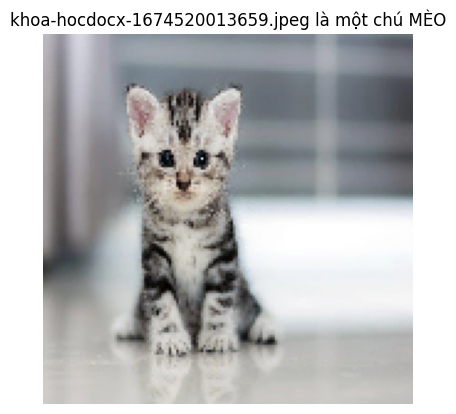

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
  # Dự đoán hình ảnh
  path = '/content/' + fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = (x / 127.5) - 1 # Normalize giống lúc train
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)

  plt.imshow(img)
  plt.axis('off')
  if classes[0] > 0.5:
    plt.title(f"{fn} là một chú CHÓ")
  else:
    plt.title(f"{fn} là một chú MÈO")
  plt.show()